In [207]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import spearmanr

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "python_scripts" else Path.cwd().parents[1]
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])
from useful_stuff.image_processing.computational_models import get_relevant_output_layers


def annotate_spearman(ax, x, y, loc=(0.04, 0.96)):
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    valid = np.isfinite(x_arr) & np.isfinite(y_arr)
    if valid.sum() < 2:
        label = "Spearman rho = n/a"
    else:
        rho, _ = spearmanr(x_arr[valid], y_arr[valid])
        label = f"Spearman rho = {rho:.2f}"
    ax.text(
        loc[0],
        loc[1],
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.8},
    )


In [261]:
@dataclass
class Cfg:
    monkey_name: str = "baby1"
    date: str = "240816to26"
    brain_area: str = "AIT"
    signal_RDM_metric: str = "cosine"
    model_RDM_metric: str = "cosine"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    pkg: str = "timm"
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 2.0
    alpha: float = 0.9

cfg = Cfg()
cfg


Cfg(monkey_name='baby1', date='240816to26', brain_area='AIT', signal_RDM_metric='cosine', model_RDM_metric='cosine', model_name='vit_l_16', img_size=384, new_fs=100, pkg='timm', results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), cmap_name='plasma', line_width=2.0, alpha=0.9)

In [262]:
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
print(f"{len(layers)} layers")


24 layers


In [263]:
def static_drsa_save_name(layer_name):
    return cfg.results_dir / f"static_dRSA_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"

curves = {}
missing = []
for layer_name in layers:
    save_name = static_drsa_save_name(layer_name)
    if save_name.exists():
        curves[layer_name] = np.load(save_name)["arr_0"]
    else:
        missing.append(save_name)

if not curves:
    raise FileNotFoundError(f"No static dRSA files found in {cfg.results_dir}")

print(f"loaded {len(curves)} / {len(layers)} layers")
if missing:
    print(f"missing {len(missing)} files")
    for save_name in missing[:5]:
        print(save_name)


FileNotFoundError: No static dRSA files found in /Users/tizianocausin/metrics_II_local/results

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_19332/377731816.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")


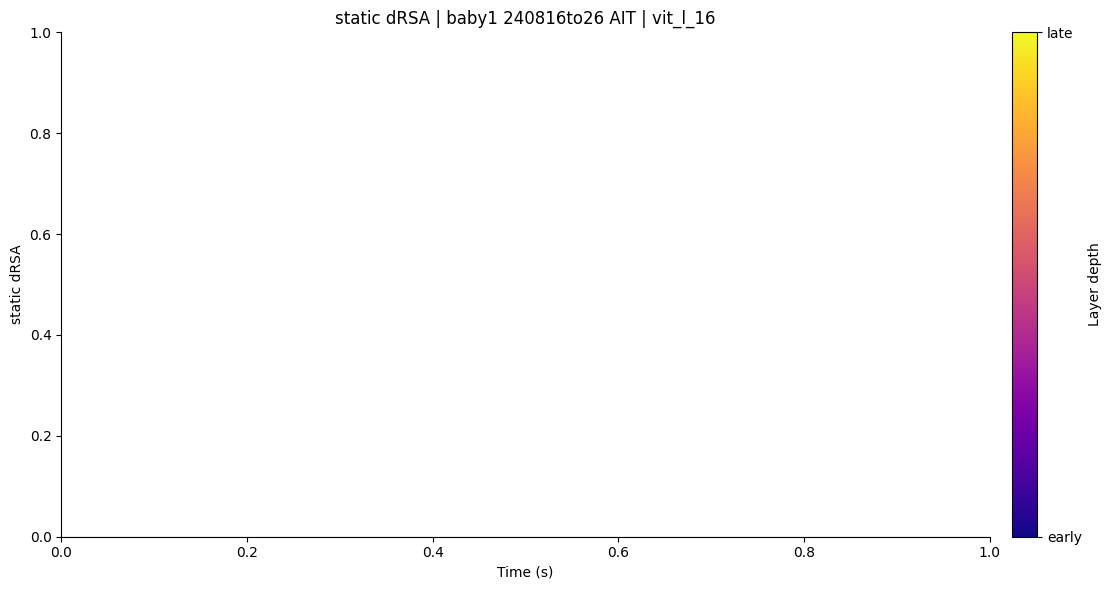

In [264]:
fig, ax = plt.subplots(figsize=(12, 6))
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for i, layer_name in enumerate(layers):
    if layer_name not in curves:
        continue
    drsa = curves[layer_name]
    t = np.arange(len(drsa)) / cfg.new_fs
    ax.plot(
        t,
        drsa,
        color=cmap(norm(i)),
        linewidth=cfg.line_width,
        alpha=cfg.alpha,
        label=layer_name,
    )

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("static dRSA")
ax.set_title(f"static dRSA | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}")
ax.spines[["top", "right"]].set_visible(False)
if len(curves) <= 12:
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


loaded layers per metric: {'euclidean': 24, 'cosine': 24, 'cosine_cnt': 24, 'correlation': 24}


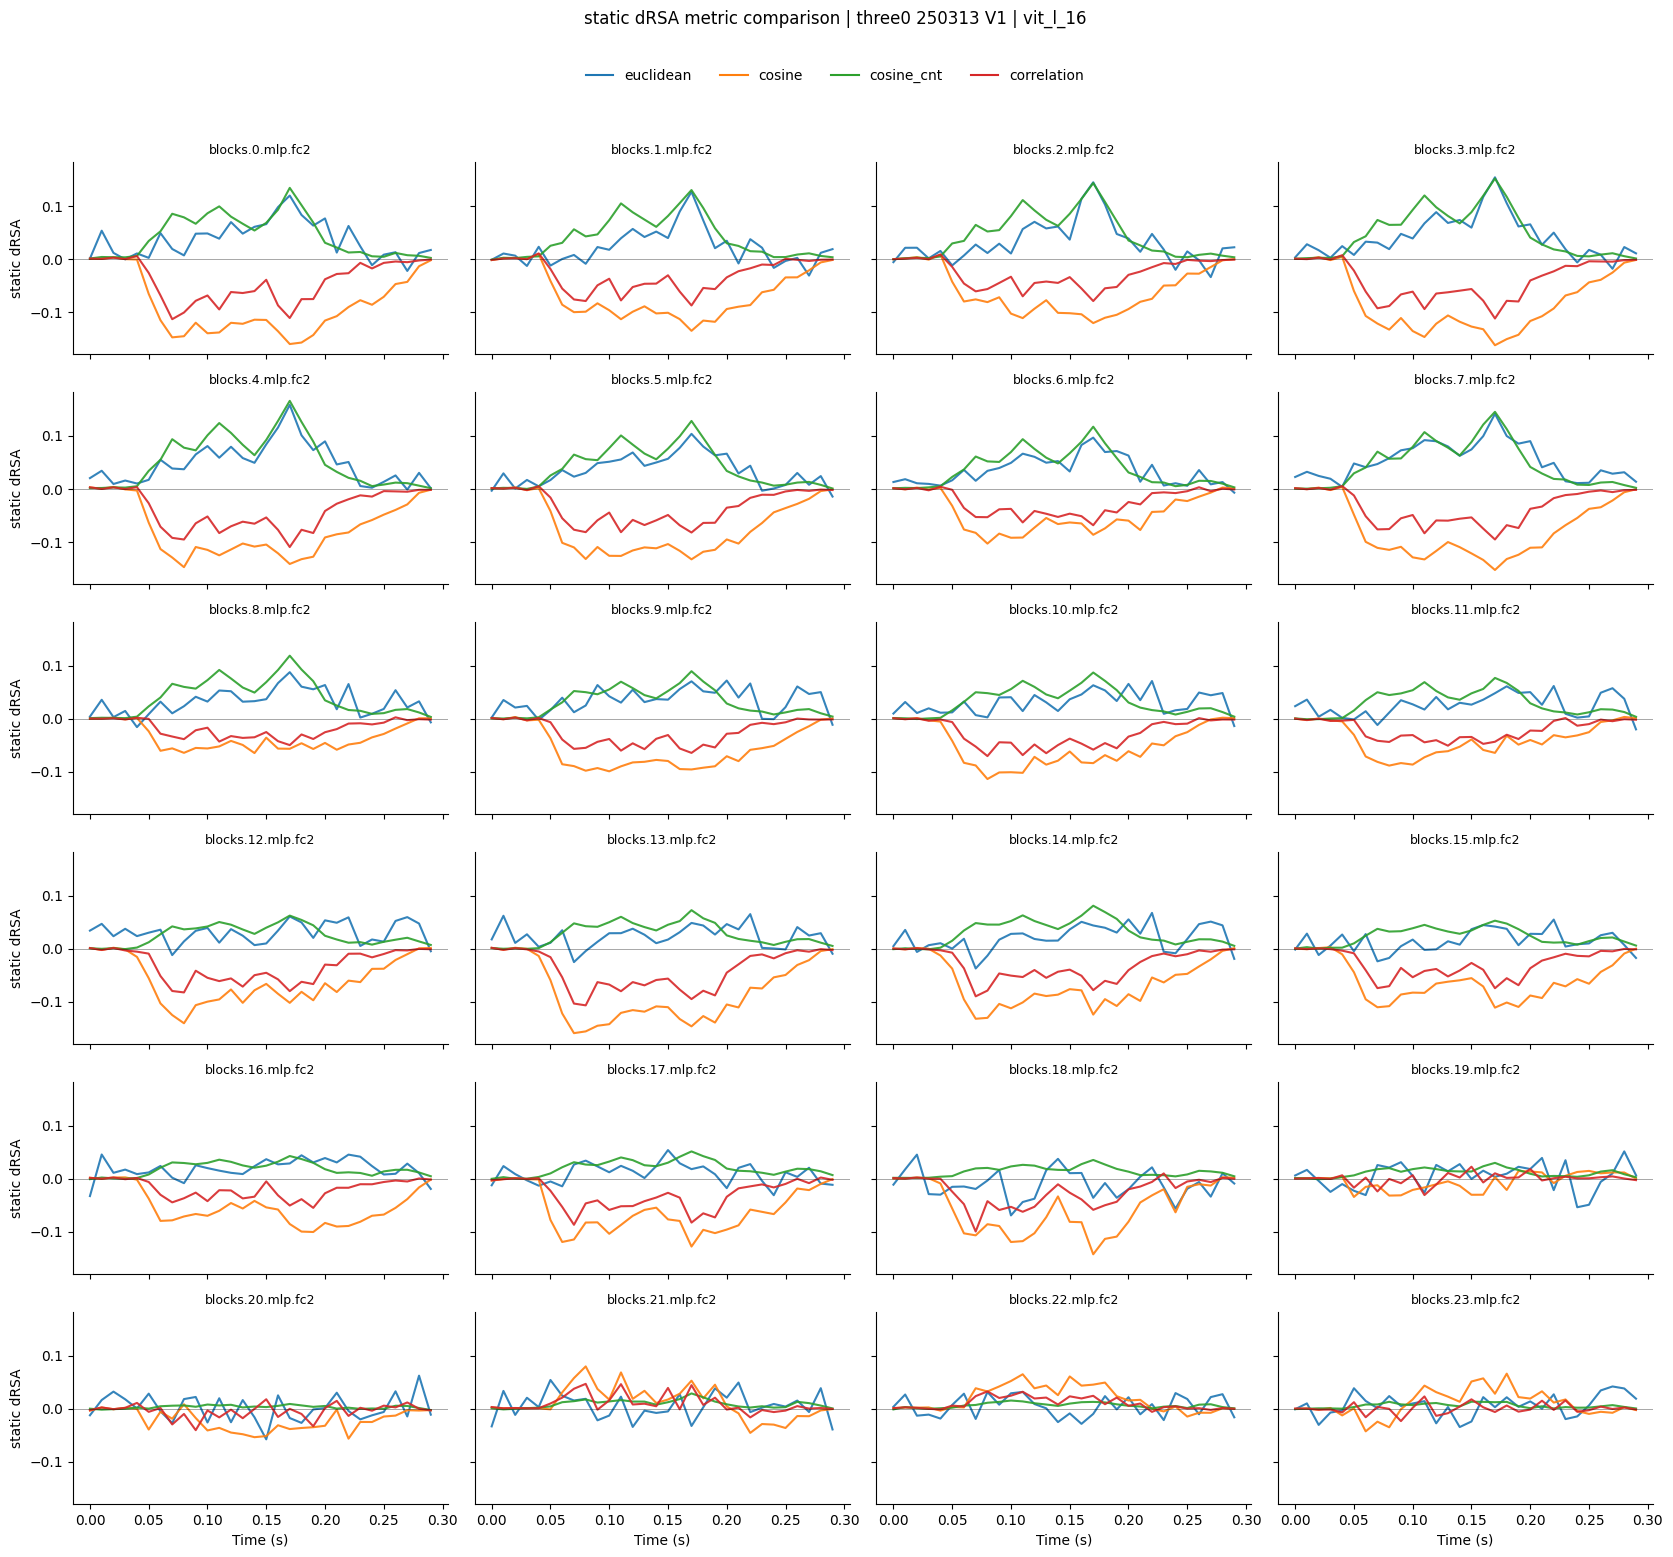

In [237]:
drsa_metrics = ("euclidean", "cosine", "cosine_cnt", "correlation")
metric_colors = {
    "euclidean": "tab:blue",
    "cosine": "tab:orange",
    "cosine_cnt": "tab:green",
    "correlation": "tab:red",
    "magnitude_diff": "black"
}


def static_drsa_metric_save_name(metric, layer_name):
    return cfg.results_dir / f"static_dRSA_{metric}-{metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"


metric_curves = {metric: {} for metric in drsa_metrics}
metric_missing = {metric: [] for metric in drsa_metrics}
for metric in drsa_metrics:
    for layer_name in layers:
        save_name = static_drsa_metric_save_name(metric, layer_name)
        if save_name.exists():
            metric_curves[metric][layer_name] = np.load(save_name)["arr_0"]
        else:
            metric_missing[metric].append(save_name)

loaded_counts = {metric: len(metric_curves[metric]) for metric in drsa_metrics}
print("loaded layers per metric:", loaded_counts)
if any(metric_missing.values()):
    print("missing files per metric:", {metric: len(paths) for metric, paths in metric_missing.items() if paths})

n_cols = 4
n_rows = int(np.ceil(len(layers) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 2.6 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.asarray(axes).ravel()

for layer_idx, layer_name in enumerate(layers):
    ax = axes[layer_idx]
    has_curve = False
    for metric in drsa_metrics:
        drsa = metric_curves[metric].get(layer_name)
        if drsa is None:
            continue
        t = np.arange(len(drsa)) / cfg.new_fs
        ax.plot(
            t,
            drsa,
            color=metric_colors[metric],
            linewidth=1.5,
            alpha=0.9,
            label=metric,
        )
        has_curve = True

    ax.axhline(0, color="black", linewidth=0.6, alpha=0.4)
    ax.set_title(layer_name, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    if not has_curve:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center")

for ax in axes[len(layers):]:
    ax.axis("off")

for ax in axes[-n_cols:]:
    ax.set_xlabel("Time (s)")
for ax in axes[::n_cols]:
    ax.set_ylabel("static dRSA")

legend_handles = [
    mpl.lines.Line2D([0], [0], color=metric_colors[metric], linewidth=1.5, label=metric)
    for metric in drsa_metrics
]
fig.legend(
    legend_handles,
    drsa_metrics,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(drsa_metrics),
)
fig.suptitle(
    f"static dRSA metric comparison | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}",
    y=0.995,
)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


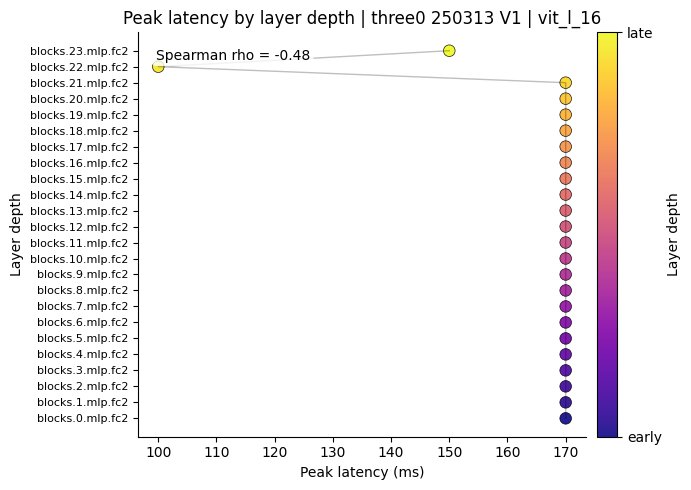

In [238]:
peak_latencies_ms = []
layer_depths = []
layer_labels = []

for layer_idx, layer_name in enumerate(layers):
    if layer_name not in curves:
        continue
    drsa = curves[layer_name]
    peak_idx = int(np.nanargmax(drsa))
    peak_latencies_ms.append(peak_idx / cfg.new_fs * 1000)
    layer_depths.append(layer_idx)
    layer_labels.append(layer_name)

fig, ax = plt.subplots(figsize=(7, 5))
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

sc = ax.scatter(
    peak_latencies_ms,
    layer_depths,
    c=layer_depths,
    cmap=cmap,
    norm=norm,
    s=70,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
)
ax.plot(peak_latencies_ms, layer_depths, color="black", linewidth=1, alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

annotate_spearman(ax, peak_latencies_ms, layer_depths)

ax.set_xlabel("Peak latency (ms)")
ax.set_ylabel("Layer depth")
ax.set_title(f"Peak latency by layer depth | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}")
ax.set_yticks(layer_depths)
ax.set_yticklabels(layer_labels, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


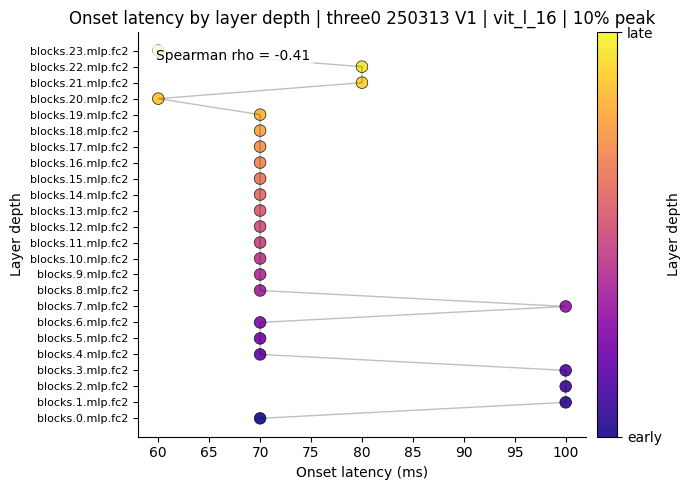

In [244]:
def get_onset_latency(curve, fs, threshold_fraction=0.10):
    arr = np.asarray(curve, dtype=float)
    if arr.ndim != 1:
        raise ValueError("curve must be 1D.")

    if not (0 <= threshold_fraction <= 1):
        raise ValueError("threshold_fraction must be in [0, 1].")

    if np.all(np.isnan(arr)):
        return np.nan

    peak = np.nanmax(arr)
    if not np.isfinite(peak) or peak <= 0:
        return np.nan

    crossing_idx = np.flatnonzero(arr >= peak * threshold_fraction)
    if crossing_idx.size == 0:
        return np.nan

    return crossing_idx[0] / fs


onset_latencies_ms = []
onset_layer_depths = []
onset_layer_labels = []

for layer_idx, layer_name in enumerate(layers):
    if layer_name not in curves:
        continue
    onset_s = get_onset_latency(curves[layer_name], fs=cfg.new_fs, threshold_fraction=0.50)
    onset_latencies_ms.append(onset_s * 1000)
    onset_layer_depths.append(layer_idx)
    onset_layer_labels.append(layer_name)

fig, ax = plt.subplots(figsize=(7, 5))
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

sc = ax.scatter(
    onset_latencies_ms,
    onset_layer_depths,
    c=onset_layer_depths,
    cmap=cmap,
    norm=norm,
    s=70,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
)
ax.plot(onset_latencies_ms, onset_layer_depths, color="black", linewidth=1, alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

annotate_spearman(ax, onset_latencies_ms, onset_layer_depths)

ax.set_xlabel("Onset latency (ms)")
ax.set_ylabel("Layer depth")
ax.set_title(f"Onset latency by layer depth | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name} | 10% peak")
ax.set_yticks(onset_layer_depths)
ax.set_yticklabels(onset_layer_labels, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


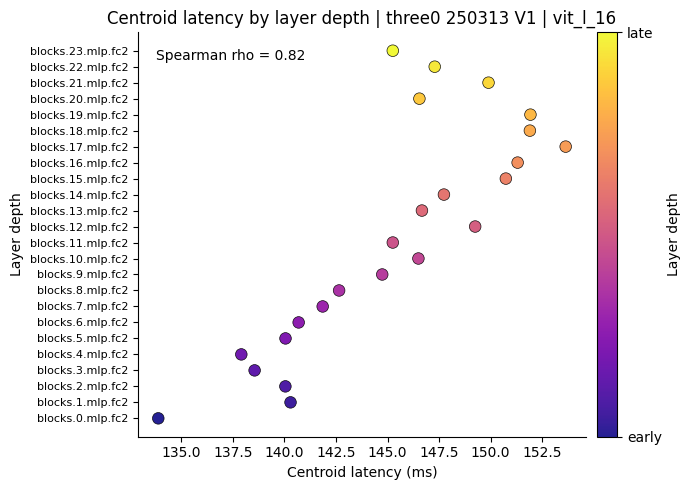

In [242]:
def get_static_centroid(curve, fs, min_peak_percent=None):
    arr = np.asarray(curve, dtype=float)
    if arr.ndim != 1:
        raise ValueError("curve must be 1D.")

    weights = np.where(arr > 0, arr, 0.0)
    if min_peak_percent is not None:
        if not (0 <= min_peak_percent <= 1):
            raise ValueError("min_peak_percent must be in [0, 1].")
        peak = weights.max()
        weights = np.where(weights >= peak * min_peak_percent, weights, 0.0)

    denom = weights.sum()
    if denom == 0:
        return np.nan

    t = np.arange(arr.size, dtype=float) / fs
    return (weights * t).sum() / denom


centroid_latencies_ms = []
centroid_layer_depths = []
centroid_layer_labels = []

for layer_idx, layer_name in enumerate(layers):
    if layer_name not in curves:
        continue
    centroid_s = get_static_centroid(curves[layer_name], fs=cfg.new_fs)
    centroid_latencies_ms.append(centroid_s * 1000)
    centroid_layer_depths.append(layer_idx)
    centroid_layer_labels.append(layer_name)

fig, ax = plt.subplots(figsize=(7, 5))
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

sc = ax.scatter(
    centroid_latencies_ms,
    centroid_layer_depths,
    c=centroid_layer_depths,
    cmap=cmap,
    norm=norm,
    s=70,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
)
# ax.plot(centroid_latencies_ms, centroid_layer_depths, color="black", linewidth=1, alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

annotate_spearman(ax, centroid_latencies_ms, centroid_layer_depths)

ax.set_xlabel("Centroid latency (ms)")
ax.set_ylabel("Layer depth")
ax.set_title(f"Centroid latency by layer depth | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}")
ax.set_yticks(centroid_layer_depths)
ax.set_yticklabels(centroid_layer_labels, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
